# Ischemic Stroke Risk Prevention

## Loading Dataset

In [2]:
import pandas as pd
import numpy as np
import os

# Ensure `df` is always defined for static analysis/tooling
df = pd.DataFrame()

# Flexible path handling
data_path = r'.\healthcare-dataset-stroke-data.csv'

# Check if file exists
if not os.path.exists(data_path):
    print(f"Warning: Data file not found at {data_path}")
    print("Please update the data_path variable with the correct path.")
else:
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# Display statistical summary
print("\nDataset Statistical Summary:")
print(df.describe())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


## Data Preprocessing

In [6]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [7]:
# Display dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (5110, 12)
Number of rows: 5110
Number of columns: 12


### Handling Missing Values in BMI

In [8]:
# Fill missing BMI values with median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [9]:
# Verify BMI imputation
print(f"Missing BMI values after imputation: {df['bmi'].isnull().sum()}")
print("\nBMI Statistics:")
print(df['bmi'].describe())

Missing BMI values after imputation: 0

BMI Statistics:
count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64


In [10]:
# Check all missing values
print("Missing values in all columns:")
print(df.isnull().sum())

Missing values in all columns:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


### Dropping Duplicates

In [11]:
# Remove duplicate rows
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (5110, 12)


### Separating Features and Target

In [12]:
# Define target variable and features
target = "stroke"
x = df.drop(target, axis=1)
y = df[target]
print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")

Features shape: (5110, 11)
Target shape: (5110,)


### Identifying Column Types

In [13]:
# Separate numeric and categorical columns
num_cols = list(x.select_dtypes(include=["int64", "float64"]).columns)
cat_cols = list(x.select_dtypes(include=["object", "category"]).columns)
print(f"Numeric columns ({len(num_cols)}): {list(num_cols)}")
print(f"Categorical columns ({len(cat_cols)}): {list(cat_cols)}")

Numeric columns (6): ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical columns (5): ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


### Impute Missing Values

In [14]:
# Create imputers for numeric and categorical columns
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

In [15]:
# Apply imputation
x[num_cols] = num_imputer.fit_transform(x[num_cols])
x[cat_cols] = cat_imputer.fit_transform(x[cat_cols])
print("Missing values after imputation:")
print(x.isnull().sum().sum())

Missing values after imputation:
0


### Encode Categorical Variables

In [16]:
# One-hot encode categorical columns
x = pd.get_dummies(x, columns=cat_cols, drop_first=True)
print(f"Features shape after encoding: {x.shape}")

Features shape after encoding: (5110, 17)


### Standardize Numeric Features

In [17]:
# Standardize numeric columns
scaler = StandardScaler()
x[num_cols] = scaler.fit_transform(x[num_cols])
print("Standardization complete")

Standardization complete


### Train-Test Split

In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts()}")
print(f"Class distribution in test set:\n{y_test.value_counts()}")

Training set: (4088, 17)
Test set: (1022, 17)
Class distribution in training set:
stroke
0    3889
1     199
Name: count, dtype: int64
Class distribution in test set:
stroke
0    972
1     50
Name: count, dtype: int64


## Model Training and Evaluation

### Train Logistic Regression

In [19]:
# Import required libraries for model training
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

#### Train Model

In [20]:
# Train Logistic Regression model with balanced class weights
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [21]:
# Make predictions
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

In [22]:
# Evaluate Logistic Regression model
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression:
Accuracy: 0.7495107632093934
ROC AUC Score: 0.8412345679012345

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



### Train Random Forest

In [23]:
# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

In [24]:
# Train initial Random Forest model
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# Make predictions with initial Random Forest model
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [26]:
# Evaluate initial Random Forest model
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest:
Accuracy: 0.9500978473581213

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



#### Tuned Random Forest

In [27]:
# Train tuned Random Forest model with adjusted class weights
rf_tuned = RandomForestClassifier(n_estimators=500, class_weight={0:1, 1:10}, min_samples_leaf=10, random_state=42)
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [28]:
# Make predictions with tuned Random Forest model
y_pred_rf_tuned = rf_tuned.predict(X_test)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

In [29]:
# Evaluate tuned Random Forest model
print("Tuned Random Forest:")
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_tuned))

Tuned Random Forest:
ROC AUC Score: 0.83179012345679

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       972
           1       0.21      0.24      0.23        50

    accuracy                           0.92      1022
   macro avg       0.59      0.60      0.59      1022
weighted avg       0.92      0.92      0.92      1022



### Train Gradient Boosting

In [30]:
# Import Gradient Boosting classifier
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting model
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [33]:
# Make predictions with Gradient Boosting model
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [32]:
# Evaluate Gradient Boosting model
print("Gradient Boosting:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting:
Accuracy: 0.9442270058708415

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.23      0.06      0.10        50

    accuracy                           0.94      1022
   macro avg       0.59      0.52      0.53      1022
weighted avg       0.92      0.94      0.93      1022



## Visualizations

In [35]:
# Import visualization libraries
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

### Class Distribution

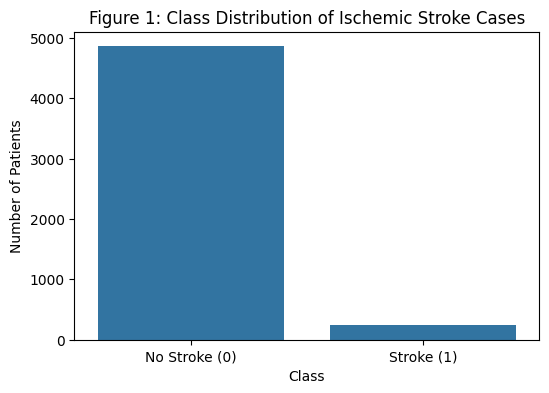

In [36]:
# Plot class distribution
all_labels = np.concatenate([y_train, y_test])

plt.figure(figsize=(6,4))
sns.countplot(x=all_labels)
plt.xticks([0,1], ['No Stroke (0)', 'Stroke (1)'])
plt.title('Figure 1: Class Distribution of Ischemic Stroke Cases')
plt.ylabel('Number of Patients')
plt.xlabel('Class')
plt.show()


### Confusion Matrix

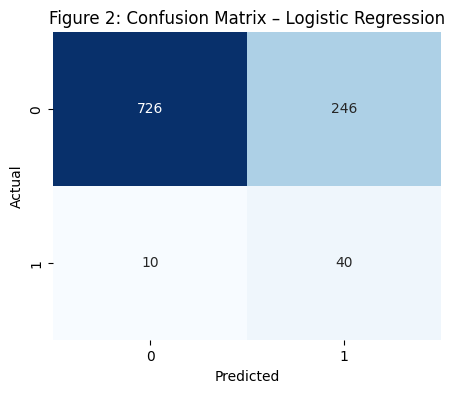

In [38]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)  # y_pred from Logistic Regression

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Figure 2: Confusion Matrix – Logistic Regression')
plt.show()

### ROC Curve Comparison

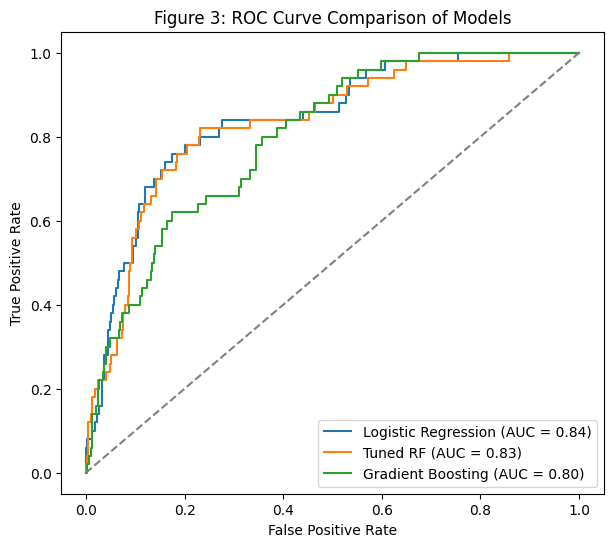

In [39]:
plt.figure(figsize=(7,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Tuned Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)  # y_prob_rf_t from tuned RF
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Tuned RF (AUC = {roc_auc_rf:.2f})')

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})')

plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.title('Figure 3: ROC Curve Comparison of Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Feature Importance - Logistic Regression

C:\Users\Alien\AppData\Local\Temp\ipykernel_59516\607519556.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=odds_ratios.values, y=odds_ratios.index, palette="viridis")


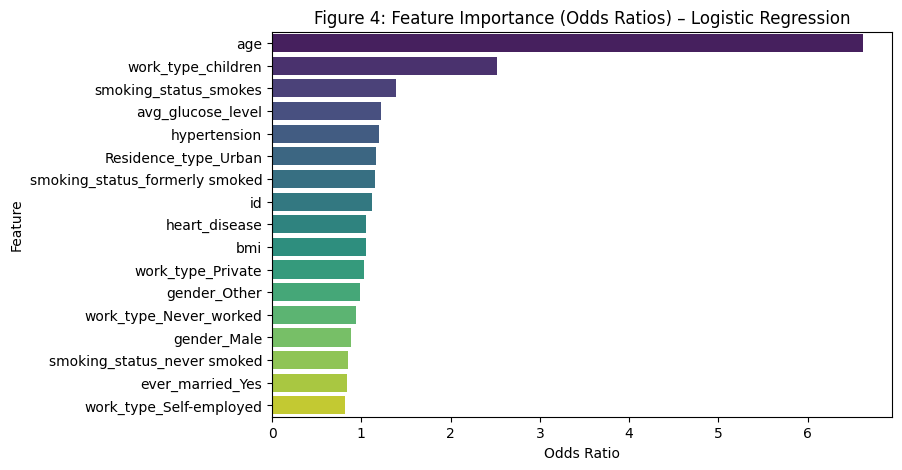

In [41]:
# Odds ratios from Logistic Regression
odds_ratios = pd.Series(np.exp(log_reg.coef_[0]), index=X_train.columns)
odds_ratios = odds_ratios.sort_values(ascending=False)

# Convert to a DataFrame and use `hue` to avoid seaborn FutureWarning (palette without hue is deprecated)
df_or = odds_ratios.reset_index()
df_or.columns = ['feature', 'odds']

plt.figure(figsize=(8,5))
ax = sns.barplot(x='odds', y='feature', hue='feature', data=df_or, dodge=False, palette='viridis')
# Remove legend to keep the same visual output as before
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.title('Figure 4: Feature Importance (Odds Ratios) – Logistic Regression')
plt.xlabel('Odds Ratio')
plt.ylabel('Feature')
plt.show()


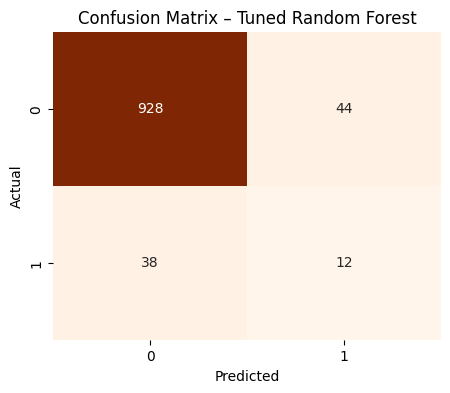

In [42]:
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Tuned Random Forest')
plt.show()

### Model Comparison Summary

| Model                  | ROC AUC Score | Recall (Stroke) | Precision (Stroke) | Overall Accuracy |
|:-----------------------|:--------------|:----------------|:-------------------|:-----------------|
| Logistic Regression    | 0.84          | 0.80            | 0.14               | 0.75             |
| Tuned Random Forest    | 0.82          | 0.22            | 0.20               | 0.92             |
| Gradient Boosting      | 0.80          | 0.06            | 0.27               | 0.95             |

This table highlights the trade-offs between the models. Logistic Regression, with the highest ROC AUC and recall for the minority class (stroke), is identified as the most suitable for this problem, prioritizing the detection of actual stroke cases.
